# TV posterior-mean example — recover a denoiser's implicit regularizer

Recover `f_reg`, the implicit regularizer of the anisotropic-TV posterior-mean
denoiser, from **denoiser evaluations alone**, with **one convex network**
(`work2.tex` Instantiation B). This notebook is a thin wrapper over the modules in
this folder (`dataset.py`, `recover.py`, `conv_icnn.py`, `step4_figures.py`,
`denoise_demo.py`) — no mathematics lives here.

> **Observations, not conclusions.** Single seed, no repeats, no error bars. Read
> the numbers as what these particular runs produced, to be confirmed (seeds,
> repeats, more images/`m`) before anything becomes a claim in the paper.

**Pipeline:** data (`u_PM` from the sampler) → model (load a shipped checkpoint, or
retrain) → held-out prox residual → qualitative figures → **the prior in action**:
denoise an image with the learned prior and compare to the true posterior-mean
denoiser. Reproduce/method/numbers: `MANUAL.md`, `DESIGN.md`, `results/`.

## Configuration

`ARCH` selects the fitter (**`fc`** = dense ICNN, default; `conv` = convolutional
ICNN). `RETRAIN=False` uses the shipped checkpoint in `results/ckpt/` (seconds);
`RETRAIN=True` retrains under the exact protocol (~2 h fc / ~13 h conv, CPU).

In [1]:
import os, sys

HERE = os.getcwd()                                   # notebooks/tv_pm/
ROOT = os.path.abspath(os.path.join(HERE, "..", ".."))   # numerics/
for p in (HERE, ROOT):
    if p not in sys.path:
        sys.path.insert(0, p)
assert os.path.isdir(os.path.join(ROOT, "src")), "run this notebook from numerics/notebooks/tv_pm/"

# ---- choices ----
ARCH    = "fc"        # "fc" (default) or "conv"
RETRAIN = False       # False: shipped checkpoint (seconds). True: retrain (~2 h fc / ~13 h conv)
SWEEPS  = 8000        # MCMC sweeps behind the cached u_PM
BETA    = 20          # Softplus sharpness, matched to the TV kink
STEPS   = 250000      # optimizer steps, if retraining
IMAGE   = "cameraman_256x256_d"   # denoising demo (transfer image); barbara_256x256_d = train dist.

import numpy as np, torch
import dataset, recover, step4_figures, denoise_demo
from IPython.display import Image
print(f"ARCH={ARCH}  RETRAIN={RETRAIN}  beta={BETA}  m={SWEEPS}  steps={STEPS}")

ARCH=fc  RETRAIN=False  beta=20  m=8000  steps=250000


## 1. Data — the sampler's `u_PM(x_k)`

The one expensive, run-once stage. Builds `data/*.npz` if absent (~15 min; samples
the posterior mean over 8×8 patches). With the cache present, instant.

In [2]:
if not os.path.exists(dataset.path("eval", SWEEPS)):
    print("sampler cache missing -> building (~15 min)...")
    os.system(f"{sys.executable} dataset.py --sweeps {SWEEPS}")

tr, va, ev = (dataset.load(s, SWEEPS) for s in ("train", "val", "eval"))
print("patches:", {k: tuple(v.shape) for k, v in
                   [("train", tr["y"]), ("val", va["y"]), ("eval", ev["y"])]})

patches: {'train': (20000, 8, 8), 'val': (4000, 8, 8), 'eval': (4000, 8, 8)}


## 2. Model — load the shipped checkpoint, or retrain

Both architectures expose the same interface, so scoring and figures below are
identical either way. Retraining a conv net first requires the convexity gate
(`test_conv_icnn.py`) to pass.

In [3]:
SHIPPED = {"fc":   "tv_pm_64D_m8000_w256_b20.0_s250000.pth",
           "conv": "tv_pm_64D_conv_m8000_C32_B2_b20.0_s250000.pth"}[ARCH]

if RETRAIN:
    recover.run(sweeps=SWEEPS, steps=STEPS, standardize=True, beta=BETA, arch=ARCH, save=True)
    tag = "w256_L2" if ARCH == "fc" else "C32_B2"
    ckpt_path = os.path.join(ROOT, "logs", "ckpt",
                             f"tv_pm_64D_{ARCH}_m{SWEEPS}_{tag}_b{float(BETA)}_s{STEPS}.pth")
else:
    ckpt_path = step4_figures.find_ckpt(SHIPPED)     # results/ckpt/ or logs/ckpt/

model, units, ck = recover.load_checkpoint(ckpt_path)
print(f"loaded {ARCH}-ICNN ({sum(p.numel() for p in model.parameters())} params) "
      f"from {os.path.relpath(ckpt_path, ROOT)}")

loaded fc-ICNN (181057 params) from logs/ckpt/tv_pm_64D_m8000_w256_b20.0_s250000.pth


### Held-out prox residual

The recovery score, with no ground truth: `‖∇J_θ(y) − (x−y)‖` on held-out patches,
relative to the target `x−y`. Read against the sampler noise floor `δ`. `eval` is
the transfer image (cameraman); `val` is the training distribution (Barbara).

In [4]:
delta = recover.estimate_delta(ev["x"], SWEEPS)
s_ev, s_va = recover.score(model, ev, units, delta), recover.score(model, va, units, delta)
print(f"sampler noise floor delta          : {100*delta:.2f} %")
print(f"prox residual  eval (cameraman)    : {100*s_ev['resid_rel']:.2f} %  "
      f"= {s_ev['ratio']:.1f} x delta   |  corr(J,TV) {s_ev['tv_corr']:+.3f}")
print(f"prox residual  val  (barbara)      : {100*s_va['resid_rel']:.2f} %  "
      f"|  corr(J,TV) {s_va['tv_corr']:+.3f}")

sampler noise floor delta          : 1.86 %
prox residual  eval (cameraman)    : 10.69 %  = 5.7 x delta   |  corr(J,TV) +0.989
prox residual  val  (barbara)      : 8.62 %  |  corr(J,TV) +0.993


## 3. Qualitative figures — what the recovered prior looks like

`J_θ` vs TV (correlated, not equal — a *smoothed* TV); the prior penalising
structure; and convex conditional slices. For the conv net, the learned first-layer
kernels — many emerge as `[+1,−1]` difference stencils, TV's building blocks.

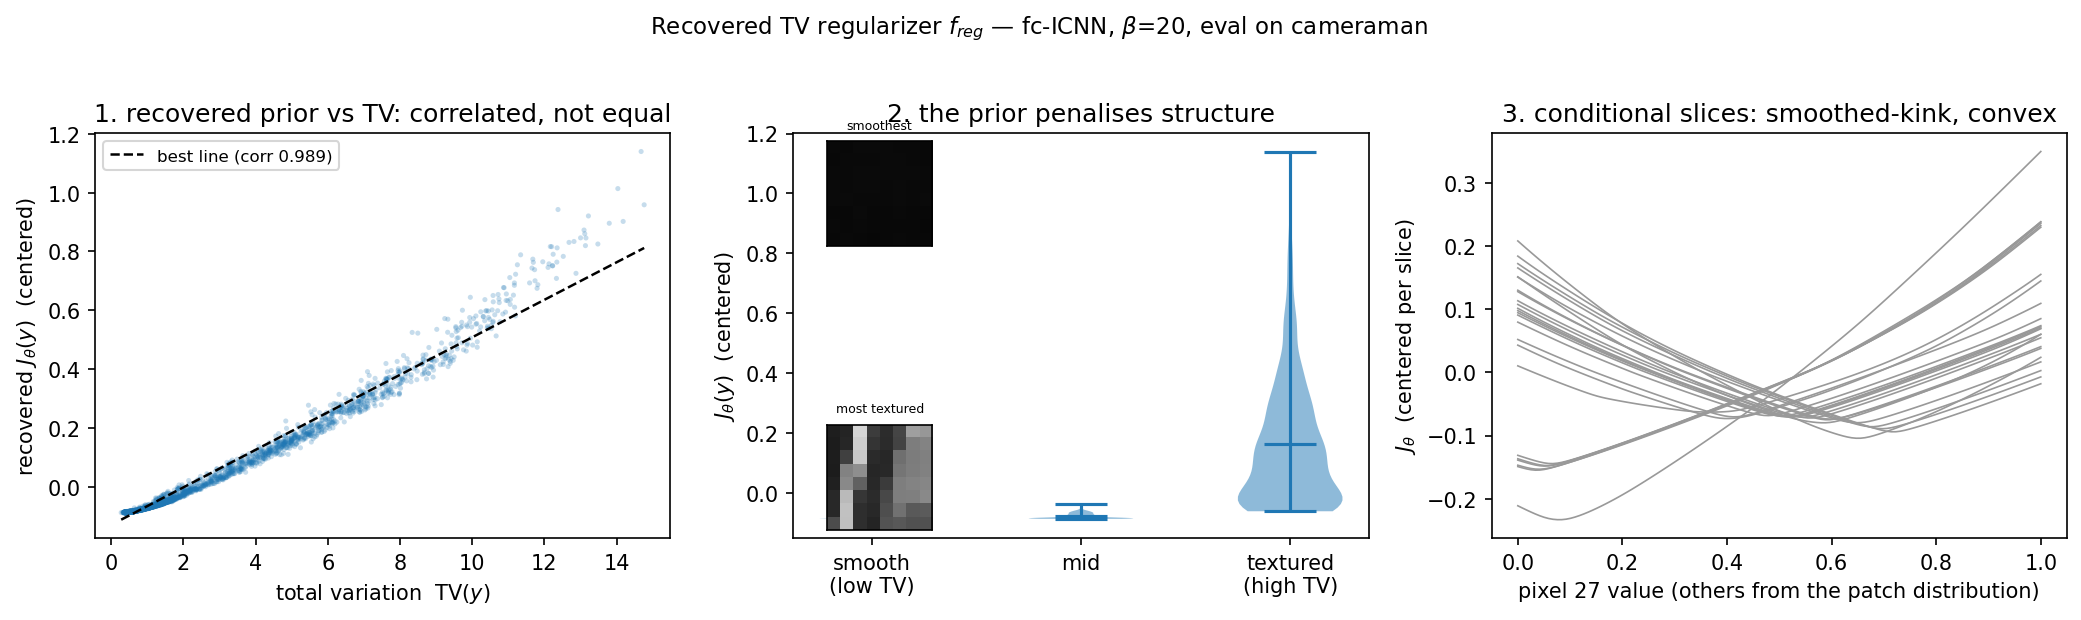

In [5]:
fig, corr = step4_figures.figure_core(model, units.mu, units.s,
                                      {"arch": ARCH, "beta": BETA}, ev)
p = os.path.join(HERE, "results", "figs", f"step4_core_{ARCH}.png")
fig.savefig(p, dpi=150, bbox_inches="tight"); import matplotlib.pyplot as plt; plt.close(fig)
Image(filename=p)

In [6]:
if ARCH == "conv":
    fk = step4_figures.figure_kernels(model, {"arch": ARCH})
    pk = os.path.join(HERE, "results", "figs", f"step4_kernels_{ARCH}.png")
    fk.savefig(pk, dpi=150, bbox_inches="tight"); plt.close(fk)
    display(Image(filename=pk))
else:
    print("learned-kernel figure is conv-only (set ARCH='conv')")

learned-kernel figure is conv-only (set ARCH='conv')


## 4. The prior in action — denoise, and compare to the true denoiser

The posterior-mean denoiser **is** the proximal operator of `f_reg`, so if the
recovery is faithful the prox of the *learned* prior must reproduce it:
`û(x) = argmin_u J_θ(u) + ½‖u−x‖² ≈ u_PM(x)`. Convex program (ICNN + quadratic),
solved by L-BFGS. Ground truth `u_PM` is the sampler's, not the clean image. Lead
metric: **relative L2** (comparable to the prox residual above); PSNR/SSIM alongside.

  image cameraman_256x256_d (256x256), 1024 patches of 8x8, sigma=0.0391
  running the sampler for u_PM (ground-truth denoiser)...


  solving prox of the learned fc-ICNN prior...


  prox optimality residual (max over patches): 6.59e-04

  vs clean       PSNR / SSIM :  noisy 28.33/0.640  |  u_PM 29.56/0.854  |  u_hat 28.84/0.850
  u_hat vs u_PM (the match)  :  PSNR 43.70 dB  |  SSIM 0.9987  |  rel-L2 1.25 %   <- learned prior REPRODUCES the denoiser


  -> /Users/gabrielpl/Claude/research/work_papers/dl_hj_eq/numerics/notebooks/tv_pm/results/figs/denoise_fc_cameraman.png/pdf


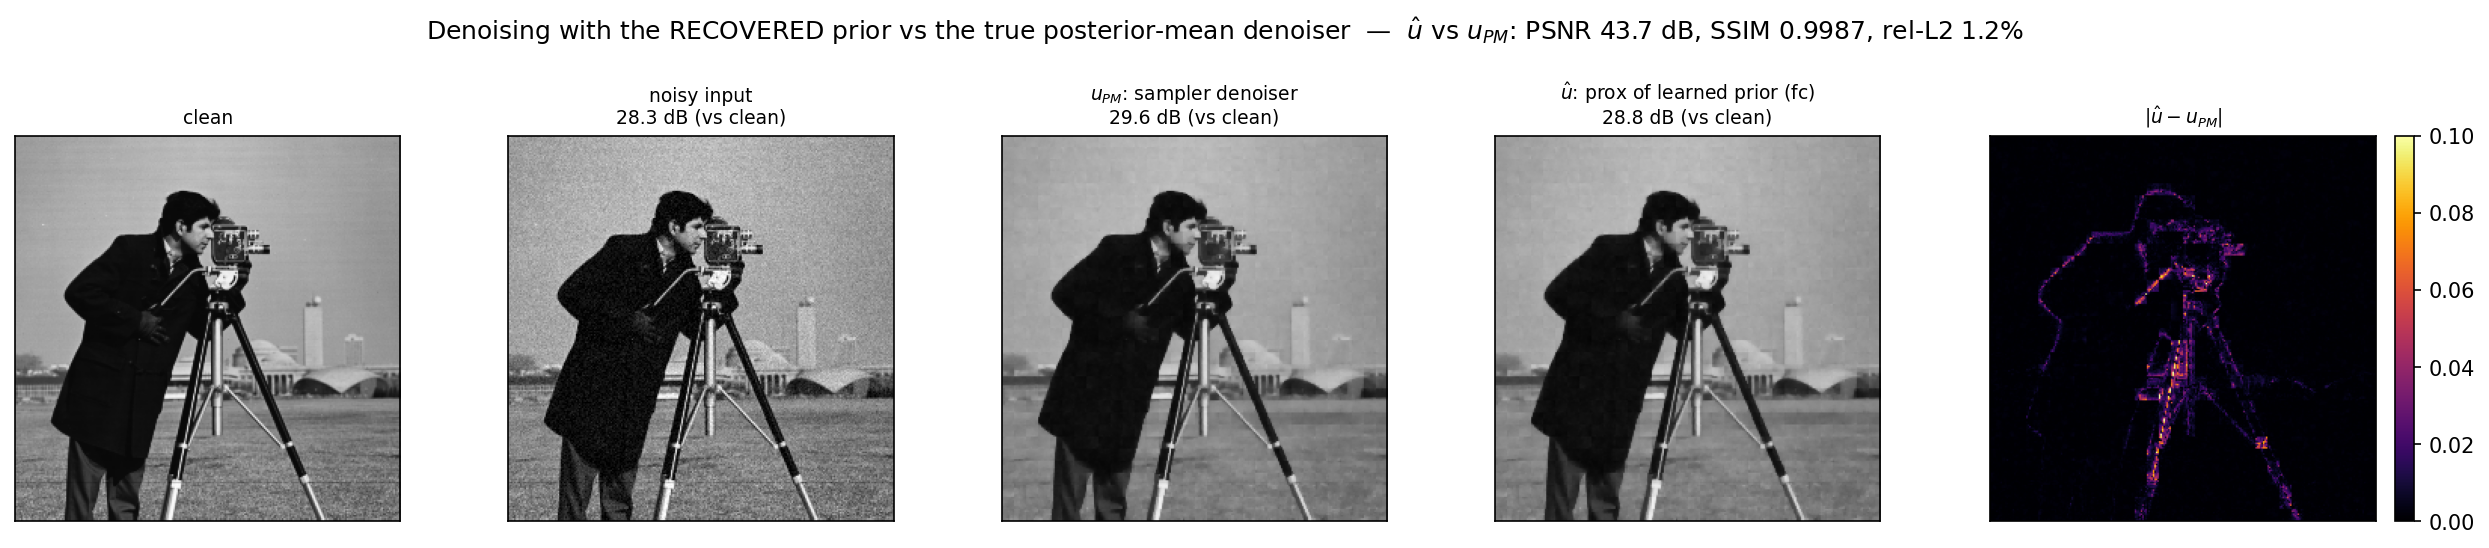

In [7]:
res = denoise_demo.run(image=IMAGE, arch=ARCH, sweeps=SWEEPS)
Image(filename=os.path.join(HERE, "results", "figs",
                            f"denoise_{ARCH}_{IMAGE.split('_')[0]}.png"))

## 5. Cost — the learned prior is far cheaper than the sampler

The payoff of learning the prior, quantified. Computing the posterior mean `u_PM`
needs MCMC **for every new image**; the learned prior denoises with a **single
sub-second convex solve**, trained once and then amortized. `denoise_demo` above
runs *both* only to compare against ground truth — in deployment you run just the
prox. (Times below are on this machine, one 256x256 image; observations.)

In [8]:
import time
from scipy.io import loadmat
from sampler import sample_pm
from denoise_demo import tile, prox_of_Jtheta

img = np.asarray(loadmat(os.path.join(ROOT, "ideas", "old_files", IMAGE + ".mat"))[IMAGE], float)
xn = tile(img)
xn = np.clip(xn + np.random.default_rng(3).normal(0, dataset.SIGMA, xn.shape), 0, 1)

t = time.time(); sample_pm(xn, dataset.SIGMA, dataset.LAM, sweeps=SWEEPS, w=1.0, seed=100)
t_pm = time.time() - t

mu_t, s_t = torch.tensor(units.mu).float(), torch.tensor(units.s).float()
t = time.time(); prox_of_Jtheta(model, mu_t, s_t, xn)
t_hat = time.time() - t

print(f"u_PM   (sampler, m={SWEEPS})              : {t_pm:6.1f} s   <- MCMC, rerun per image")
print(f"u_hat  (prox of the learned {ARCH} prior)   : {t_hat:6.2f} s   <- trained once, then this")
print(f"speedup at the production budget           : {t_pm/t_hat:5.0f}x")

u_PM   (sampler, m=8000)              :   26.7 s   <- MCMC, rerun per image
u_hat  (prox of the learned fc prior)   :   0.18 s   <- trained once, then this
speedup at the production budget           :   149x


## Summary (observed)

- The learned prior recovers `f_reg` to a **~10.7 % held-out prox residual** with
  **corr(J, TV) ≈ 0.99**, and — the point of §4 — its prox **reproduces the
  posterior-mean denoiser** (rel-L2 ~0.2–1.3 %, edges only in the difference).
- `fc` and `conv` tie on the residual; `conv` reproduces the denoiser better on
  transfer but runs 5–6× slower (more FLOPs despite fewer parameters).
- More MCMC sweeps keep improving the recovery (see the `m`-sweep in `results/`),
  so ~10.7 % at the production budget is not a hard limit.
- **Denoising with the learned prior is ~2 orders of magnitude faster than the
  MCMC** it was learned from — a sub-second prox vs ~27 s of sampler at the
  production budget (roughly 50–150×, depending on the solver tolerance) — and the
  sampler must rerun per image while the prior is trained once: the amortization payoff.

All of this is single-seed and preliminary — see the caveat at the top. Full record:
`../changes.txt`; shareable numbers and figures: `results/`.